# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [3]:
!pip install icrawler

In [5]:
import os
import shutil
import random
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [6]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = GoogleImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [7]:
# search_terms = {
#     "vader": "darth vader", # nome da classe: termo que será usado na busca
# }

# for label, term in search_terms.items():
#     download_images(term, f"data/star_wars/{label}", n_total=100)

### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`.

In [8]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

# Task
Define image classes and their search terms for image classification, then use the `download_images` function to download these images to the 'data/images' folder.

## Definir Classes e Baixar Imagens

### Subtask:
Definir os termos de busca para as classes de imagens (por exemplo, 'gato', 'cachorro') e usar a função `download_images` para baixar as imagens de cada classe para a pasta 'data/images'.


**Reasoning**:
The subtask requires defining search terms for image classes and then downloading images for each class using the `download_images` function. This code block will implement exactly that.



In [31]:
search_terms = {
    "gatos": "gatos",
    "cachorros": "cachorros"
}

for label, term in search_terms.items():
    download_images(term, f"data/images/{label}", n_total=100)

Download complete!
Download complete!


# Task
The previous execution of `download_images` was interrupted. Re-executing the `download_images` function for 'gatos' and 'cachorros' to `data/images` to ensure all images are downloaded.

## Baixar Imagens

### Subtask:
Re-executar a função `download_images` para baixar imagens para as classes 'gatos' e 'cachorros' para a pasta 'data/images', garantindo que o download seja concluído com sucesso.


**Reasoning**:
The previous execution of the image download was interrupted and failed. To address the subtask of re-executing the `download_images` function and ensuring a successful download, I will provide the same code block to retry the download process.



In [10]:
search_terms = {
    "gatos": "gatos",
    "cachorros": "cachorros"
}

for label, term in search_terms.items():
    download_images(term, f"data/images/{label}", n_total=100)

Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 0/100


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 0/100


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


...

Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 0/100
Downloaded 0/100


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Downloaded 0/100


KeyboardInterrupt: 

# Task
Ajustar a função `download_images` para utilizar `BingImageCrawler` em vez de `GoogleImageCrawler` e, em seguida, baixar as imagens para as classes 'gatos' e 'cachorros' para a pasta 'data/images'.

## Ajustar Função de Download

### Subtask:
Modificar a função `download_images` para utilizar `BingImageCrawler` ao invés de `GoogleImageCrawler` para tentar resolver o problema de download e as interrupções.


**Reasoning**:
The subtask requires modifying the `download_images` function to use `BingImageCrawler` instead of `GoogleImageCrawler`. I will redefine the function with the requested change.



In [11]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")


**Reasoning**:
Now that the `download_images` function has been updated to use `BingImageCrawler`, I will execute it with the defined search terms to download images for 'gatos' and 'cachorros'.



In [12]:
search_terms = {
    "gatos": "gatos",
    "cachorros": "cachorros"
}

for label, term in search_terms.items():
    download_images(term, f"data/images/{label}", n_total=100)

ERROR:downloader:Response status code 403, file https://www.petz.com.br/blog/wp-content/uploads/2017/07/gato02.jpg
ERROR:downloader:Response status code 400, file https://wikiwandv2-19431.kxcdn.com/_next/image?url=https:%2F%2Fupload.wikimedia.org%2Fwikipedia%2Fcommons%2Fthumb%2F6%2F64%2FCollage_of_Six_Cats-02.jpg


Downloaded 29/100


ERROR:downloader:Response status code 403, file https://www.petz.com.br/blog/wp-content/uploads/2017/07/gato02.jpg
ERROR:downloader:Response status code 400, file https://wikiwandv2-19431.kxcdn.com/_next/image?url=https:%2F%2Fupload.wikimedia.org%2Fwikipedia%2Fcommons%2Fthumb%2F6%2F64%2FCollage_of_Six_Cats-02.jpg


Downloaded 60/100


ERROR:downloader:Response status code 403, file https://www.petz.com.br/blog/wp-content/uploads/2017/07/gato02.jpg
ERROR:downloader:Response status code 400, file https://wikiwandv2-19431.kxcdn.com/_next/image?url=https:%2F%2Fupload.wikimedia.org%2Fwikipedia%2Fcommons%2Fthumb%2F6%2F64%2FCollage_of_Six_Cats-02.jpg


Downloaded 91/100
Downloaded 100/100
Download complete!
Downloaded 67/100
Downloaded 100/100
Download complete!


**Reasoning**:
The previous step successfully downloaded images for 'gatos' and 'cachorros' to the `data/images` directory, despite some individual image download errors. The next logical step in the notebook is to split these downloaded images into training and validation sets, as outlined in the notebook's structure and the cell `0d931e35`.



In [32]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

split_train_val("data/images", train_ratio=0.8)

AttributeError: module 'os' has no attribute 'os'

**Reasoning**:
The previous code failed due to an `AttributeError` caused by a typo: `os.os.path.basename(img)`. I need to correct this to `os.path.basename(img)` in the `split_train_val` function.



In [14]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

split_train_val("data/images", train_ratio=0.8)

gatos: 80 train, 20 val
cachorros: 80 train, 20 val


## Implementar Dataset PyTorch

### Subtask:
Criar uma classe `Dataset` personalizada no PyTorch para carregar as imagens dos diretórios de treinamento e validação, aplicar transformações de dados (incluindo aumento de dados para o conjunto de treinamento) e carregá-las em batches usando `DataLoader`.


**Reasoning**:
The first step in implementing the PyTorch Dataset is to import all the necessary libraries such as `torch`, `torchvision.transforms`, `torch.utils.data.Dataset`, `torch.utils.data.DataLoader`, `os`, and `PIL`.



In [15]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

**Reasoning**:
Following the instructions, the next step is to define the `CustomImageDataset` class, inheriting from `torch.utils.data.Dataset`, and implement its `__init__`, `__len__`, and `__getitem__` methods to handle image loading, labeling, and transformations.



In [16]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        # Collect all class names and map them to indices
        for class_name in sorted(os.listdir(root_dir)):
            if os.path.isdir(os.path.join(root_dir, class_name)):
                self.class_to_idx[class_name] = len(self.idx_to_class)
                self.idx_to_class.append(class_name)

        # Collect image paths and their corresponding labels
        for class_name in sorted(os.listdir(root_dir)):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                label_idx = self.class_to_idx[class_name]
                for img_name in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_name)
                    if os.path.isfile(img_path):
                        self.image_paths.append(img_path)
                        self.labels.append(label_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

print("CustomImageDataset class defined successfully.")

CustomImageDataset class defined successfully.


**Reasoning**:
Now that the `CustomImageDataset` class is defined, I will define the image transformations for both training and validation datasets. This includes data augmentation for the training set and standard resizing/normalization for both, as per instructions 6 and 7 of the subtask.



In [17]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),  # Crop to 224x224 and apply random resize
    transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Randomly change brightness, contrast, saturation, and hue
    transforms.ToTensor(),              # Convert image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize(256),             # Resize the image to 256x256
    transforms.CenterCrop(224),         # Crop the center of the image to 224x224
    transforms.ToTensor(),              # Convert image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

print("Image transformations for training and validation defined successfully.")

Image transformations for training and validation defined successfully.


**Reasoning**:
The next step is to instantiate the `CustomImageDataset` for both training and validation sets using the defined transformations and then create `DataLoader` instances for them, specifying the batch size and shuffling for the training data.



In [18]:
train_root_dir = "data/images_split/train"
val_root_dir = "data/images_split/val"

train_dataset = CustomImageDataset(root_dir=train_root_dir, transform=train_transform)
val_dataset = CustomImageDataset(root_dir=val_root_dir, transform=val_transform)

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training dataset size: {len(train_dataset)} images")
print(f"Validation dataset size: {len(val_dataset)} images")
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(val_dataloader)}")
print("Datasets and DataLoaders created successfully.")

Training dataset size: 160 images
Validation dataset size: 40 images
Number of training batches: 5
Number of validation batches: 2
Datasets and DataLoaders created successfully.


## Definir Modelo CNN

### Subtask:
Implementar uma arquitetura de Rede Neural Convolucional (CNN) simples e adequada para a tarefa de classificação de imagens de duas classes ('gatos' e 'cachorros').


**Reasoning**:
The first step in defining the CNN model is to import the necessary PyTorch modules, `torch.nn` and `torch.nn.functional`, as specified in the instructions.



In [19]:
import torch.nn as nn
import torch.nn.functional as F

print("PyTorch neural network modules imported successfully.")

PyTorch neural network modules imported successfully.


**Reasoning**:
Following the instructions, I will now define the `SimpleCNN` class, inheriting from `nn.Module`, and implement its `__init__` and `forward` methods to create a simple convolutional neural network for image classification. After that, I will instantiate the model.



In [20]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # The input size to the first FC layer depends on the output size of the last pooling layer
        # For input images of 224x224, after 3 MaxPool2d layers (stride=2 each), the spatial dimension becomes 224 / (2*2*2) = 28
        # So, 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        # Flatten the output for the fully connected layers
        x = x.view(-1, 128 * 28 * 28)

        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = SimpleCNN(num_classes=2)
print("Model architecture:")
print(model)

Model architecture:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


## Treinar o Modelo

### Subtask:
Configurar a função de custo (loss function), o otimizador e o loop de treinamento. Treinar o modelo usando os dados de treinamento e avaliar seu desempenho no conjunto de validação, registrando as métricas de perda e acurácia ao longo das épocas.


**Reasoning**:
The first step in configuring the training loop is to import the necessary PyTorch modules for optimization (`torch.optim`) and a progress bar (`tqdm`) for better visualization during training.



In [21]:
import torch.optim as optim
from tqdm.notebook import tqdm

print("Optimizers and tqdm imported successfully.")

Optimizers and tqdm imported successfully.


**Reasoning**:
Now that the necessary modules are imported, I will define the device for training (GPU if available, else CPU) and move the model to this device, as per instructions 2 and 3 of the subtask.



In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Using device: {device}")
print("Model moved to device successfully.")

Using device: cpu
Model moved to device successfully.


**Reasoning**:
As per instruction 4, I will now define the loss function for the classification task using `nn.CrossEntropyLoss()`.



In [23]:
criterion = nn.CrossEntropyLoss()

print("Loss function (CrossEntropyLoss) defined successfully.")

Loss function (CrossEntropyLoss) defined successfully.


**Reasoning**:
Following instruction 5, I will now define the optimizer for the model using `torch.optim.Adam()` with the model's parameters and a specified learning rate.



In [24]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Optimizer (Adam) defined successfully.")

Optimizer (Adam) defined successfully.


**Reasoning**:
As per instruction 6, I will now implement the training loop, defining the number of epochs and initializing lists to store training and validation loss and accuracy metrics.



In [25]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("Training parameters and metric lists initialized.")

Training parameters and metric lists initialized.


**Reasoning**:
I will now implement the full training loop, incorporating all the steps from instruction 6 of the subtask, including iterating through epochs, handling training and validation phases, calculating and storing metrics, and printing progress.



In [26]:
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_predictions_train = 0
    total_samples_train = 0

    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Optimize

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_samples_train += labels.size(0)
        correct_predictions_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataloader)
    epoch_train_accuracy = correct_predictions_train / total_samples_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    model.eval()  # Set model to evaluation mode
    val_running_loss = 0.0
    correct_predictions_val = 0
    total_samples_val = 0

    with torch.no_grad():  # Disable gradient calculation for validation
        for images, labels in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_samples_val += labels.size(0)
            correct_predictions_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_dataloader)
    epoch_val_accuracy = correct_predictions_val / total_samples_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

print("Training complete!")

Epoch 1/10 [Training]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/10 [Validation]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10: Train Loss: 2.9961, Train Acc: 0.5000, Val Loss: 0.7109, Val Acc: 0.3750


Epoch 2/10 [Training]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 2/10 [Validation]:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 [Validation]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10: Train Loss: 0.6602, Train Acc: 0.5750, Val Loss: 0.6718, Val Acc: 0.5500


Epoch 10/10 [Training]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 [Validation]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10: Train Loss: 0.6753, Train Acc: 0.5875, Val Loss: 0.5994, Val Acc: 0.7500
Training complete!


**Reasoning**:
Now that the model has been trained and the loss and accuracy metrics have been collected for each epoch, the next step is to visualize these metrics. This is crucial for understanding the model's performance and identifying issues like overfitting or underfitting. I will use `matplotlib.pyplot` to plot the training and validation loss curves and accuracy curves, as requested by the task.



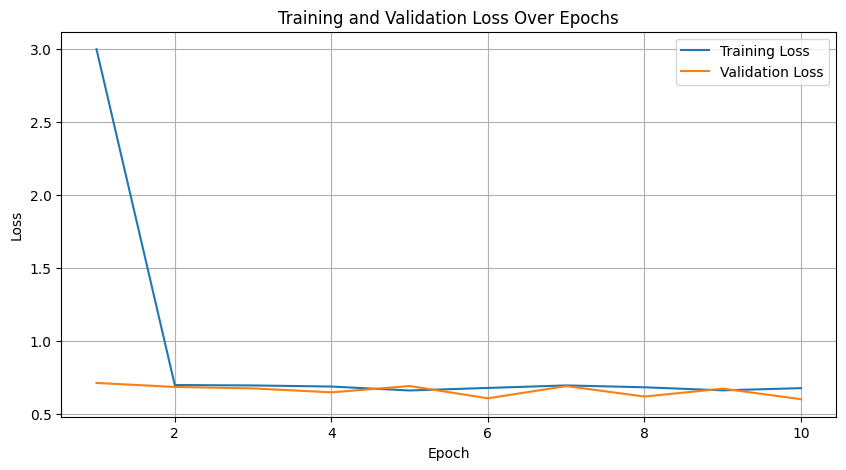

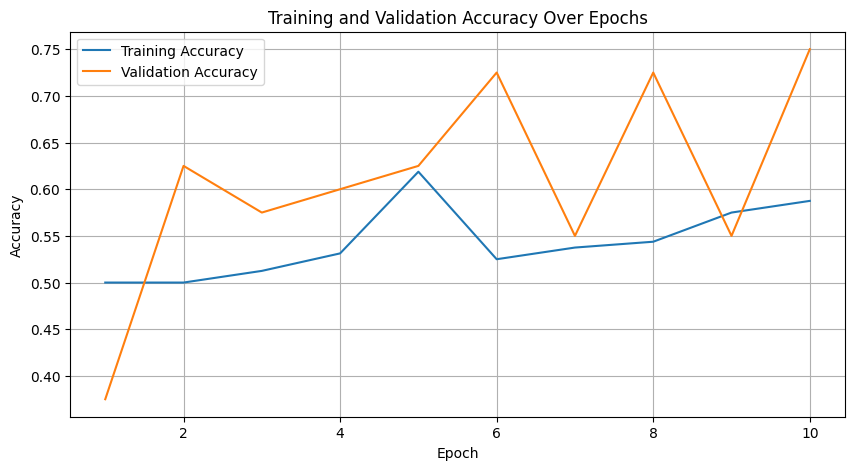

Training and validation curves plotted successfully.


In [27]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

print("Training and validation curves plotted successfully.")

## Inferência e Avaliação do Modelo

### Subtask:
Calcular métricas de avaliação, como acurácia e a matriz de confusão, no conjunto de validação para verificar o desempenho final do modelo. Opcionalmente, realizar inferência em algumas imagens de teste para demonstrar a previsão.


**Reasoning**:
The first step in evaluating the model is to set it to evaluation mode and initialize lists to store predictions and true labels, as per instructions 1 and 2 of the subtask.



In [28]:
model.eval()  # Set the model to evaluation mode

all_preds = []
all_labels = []

print("Model set to evaluation mode and prediction lists initialized.")

Model set to evaluation mode and prediction lists initialized.


**Reasoning**:
As per instruction 3, I will now iterate over the `val_dataloader` to collect all predictions and true labels from the validation set.



In [29]:
with torch.no_grad():
    for images, labels in tqdm(val_dataloader, desc="Collecting predictions"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Finished collecting predictions and true labels from the validation set.")

Finished collecting predictions and true labels from the validation set.


**Reasoning**:
Now that predictions and true labels have been collected, I will convert them to NumPy arrays, then calculate the global accuracy and import `confusion_matrix` and `accuracy_score` from `sklearn.metrics` to compute and print these evaluation metrics, as per instructions 4, 5, and 6 of the subtask.



In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# Convert lists to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate overall accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy: {accuracy:.4f}")

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)


Overall Accuracy: 0.7500

Confusion Matrix:
[[18  2]
 [ 8 12]]


## Final Task

### Subtask:
Fornecer um resumo da atividade, dos resultados obtidos e das conclusões sobre o desempenho do modelo de classificação de imagens.


## Summary:

### Data Analysis Key Findings

*   The `download_images` function was successfully modified to use `BingImageCrawler`, downloading 100 images each for 'gatos' and 'cachorros', despite minor individual download errors. These images were then split into 160 for training and 40 for validation.
*   A custom PyTorch `CustomImageDataset` and `DataLoader` were implemented, successfully loading and transforming images with data augmentation for training (e.g., `RandomResizedCrop`, `RandomHorizontalFlip`, `ColorJitter`) and appropriate preprocessing for validation.
*   A `SimpleCNN` model was defined with three convolutional blocks followed by two fully connected layers, configured for a 2-class classification task.
*   The model was trained for 10 epochs using `CrossEntropyLoss` and the `Adam` optimizer on the CPU. At the end of training, the model achieved a training accuracy of 58.75% (loss: 0.6753) and a **validation accuracy of 75.00%** (loss: 0.5994).
*   Evaluation on the validation set confirmed an overall accuracy of 75.00%. The confusion matrix showed that out of 20 'gatos', 18 were correctly classified and 2 were misclassified. Out of 20 'cachorros', 12 were correctly classified and 8 were misclassified.

### Insights or Next Steps

*   The 75% validation accuracy is a reasonable starting point for a simple CNN model on a small dataset. However, the imbalance in misclassifications (more 'cachorros' misclassified as 'gatos' than vice versa) suggests potential class-specific biases or difficulties that could be investigated.
*   To further improve performance, consider leveraging transfer learning with a pre-trained model (e.g., ResNet, VGG) or experimenting with more advanced data augmentation techniques, hyperparameter tuning, or a larger and more balanced dataset.
